# Advertising Budget & Revenue Analysis
## The ISL Marketing Plan: Answering 7 Business Questions with Linear Regression

---

### Business Context

A company allocates marketing budgets across **three advertising channels** — TV, Radio, and Newspaper —
to drive product revenue across 200 independent markets. Following ISL Chapter 3.4, we answer
**seven research questions** that guide budget allocation decisions.

| Q | Research Question | Statistical Tool |
|---|---|---|
| Q1 | Is there a relationship between advertising budget and revenue? | F-test (MLR) |
| Q2 | How strong is the relationship? | R², RSE |
| Q3 | Which media channels contribute to revenue? | t-tests, SLR per channel |
| Q4 | How accurately can we estimate each channel's effect? | 95% Confidence Intervals |
| Q5 | How accurately can we predict future revenue? | Train/Test RMSE, KNN comparison |
| Q6 | Is the relationship linear? | LINE diagnostics, Shapiro-Wilk, VIF |
| Q7 | Is there synergy among the advertising media? | TV × Radio interaction term |

### Dataset

- **Source:** Advertising Budget and Sales dataset (n = 200 independent markets)
- **Features (X):** TV, Radio, Newspaper ad budgets (in $K)
- **Target (y):** Revenue (in $K)


---
## 1. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')


# Corporate colour palette for consistent reporting
COLORS = {
    'tv':        '#1A6FAF',   # blue  — TV
    'radio':     '#2EAA6E',   # green — Radio
    'newspaper': '#E07B39',   # orange — Newspaper
    'mlr':       '#8B5CF6',   # purple — MLR full model
    'knn':       '#E74C3C',   # red — KNN
    'accent':    '#F4A825',   # gold — highlights
    'dark':      '#1A2A4A',   # navy text
    'light':     '#F4F8FA',   # light background
}

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F9FBFC',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.family':      'DejaVu Sans',
    'axes.labelsize':   12,
    'axes.titlesize':   13,
    'figure.titlesize': 15,
})

OUTPUT_DIR = Path('../output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Libraries loaded. Output directory ready.')

Libraries loaded. Output directory ready.


In [2]:

DATA_PATH = Path('../data/advertising_budget_and_sales.csv')
df = pd.read_csv(DATA_PATH, index_col=0)
df.columns = ['TV', 'Radio', 'Newspaper', 'Sales']

# Rename Sales → Revenue for business-facing reporting
df = df.rename(columns={'Sales': 'Revenue'})

print(f'Dataset shape: {df.shape[0]} markets × {df.shape[1]} variables')
print()
print('First 5 rows:')
display(df.head())

Dataset shape: 200 markets × 4 variables

First 5 rows:


,TV,Radio,Newspaper,Revenue
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


---
## 2. Exploratory Data Analysis (EDA)

Before building any model, we inspect the data distribution, correlations, and variable relationships.
This answers **Q1** (is there a relationship?) at a visual level.

In [3]:
# ─── 2.1 Descriptive Statistics
desc = df.describe().T
desc['CV%'] = (desc['std'] / desc['mean'] * 100).round(1)   # Coefficient of Variation
display(desc.round(2))

print()
print('Key observations:')
print(f'  • Average revenue across all markets: ${df["Revenue"].mean():.1f}K')
print(f'  • TV dominates spend: avg ${df["TV"].mean():.1f}K vs Radio ${df["Radio"].mean():.1f}K vs Newspaper ${df["Newspaper"].mean():.1f}K')
print(f'  • Revenue ranges widely: ${df["Revenue"].min():.1f}K – ${df["Revenue"].max():.1f}K')

,count,mean,std,min,25%,50%,75%,max,CV%
TV,200.0,147.04,85.85,0.7,74.38,149.75,218.82,296.4,58.4
Radio,200.0,23.26,14.85,0.0,9.98,22.90,36.52,49.6,63.8
Newspaper,200.0,30.55,21.78,0.3,12.75,25.75,45.10,114.0,71.3
Revenue,200.0,14.02,5.22,1.6,10.38,12.90,17.40,27.0,37.2



Key observations:
  • Average revenue across all markets: $14.0K
  • TV dominates spend: avg $147.0K vs Radio $23.3K vs Newspaper $30.6K
  • Revenue ranges widely: $1.6K – $27.0K


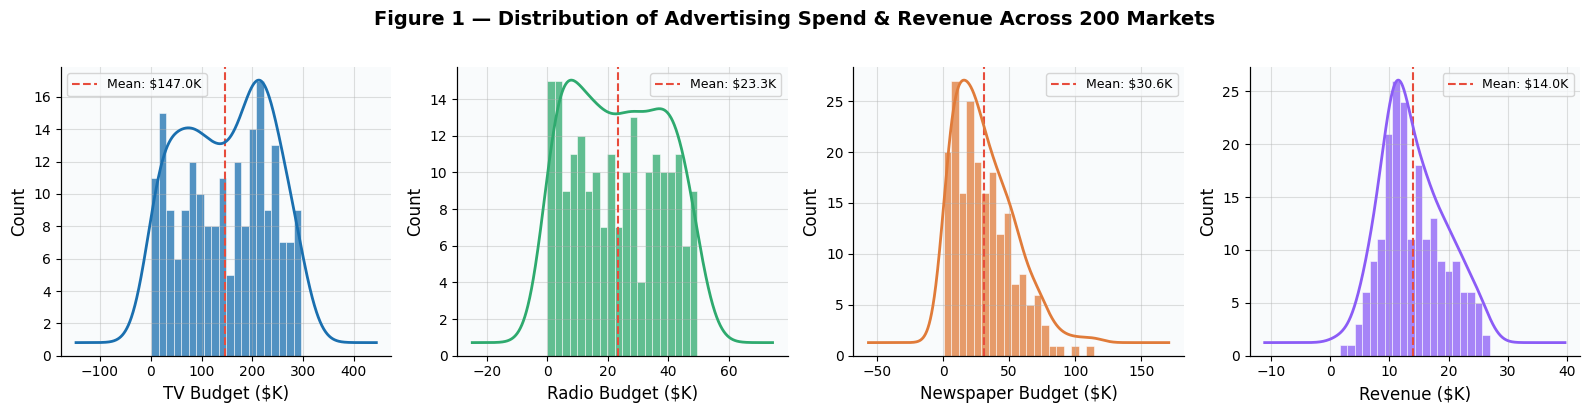


Chart Explanation — Figure 1 (Variable Distributions):
  TV budget is right-skewed: most markets spend $50–200K, a few push above $250K.
  Radio and Newspaper are more evenly spread. Revenue is roughly bell-shaped
  centred around $14K, suggesting linear relationships may hold well.
  No extreme outliers that would distort the regression.


In [4]:
# ─── 2.2 Figure 1: Distribution of Each Variable ─────────────────────────────
#
# Purpose: Understand the spread and shape of each variable before modelling.
# Histograms show whether any variable is heavily skewed, which would affect
# model assumptions. KDE curves overlay the smooth density estimate.

channels = ['TV', 'Radio', 'Newspaper', 'Revenue']
ch_colors = [COLORS['tv'], COLORS['radio'], COLORS['newspaper'], COLORS['mlr']]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Figure 1 — Distribution of Advertising Spend & Revenue Across 200 Markets',
             fontsize=14, fontweight='bold', y=1.02)

for ax, col, color in zip(axes, channels, ch_colors):
    ax.hist(df[col], bins=20, color=color, alpha=0.75, edgecolor='white', linewidth=0.5)
    ax2 = ax.twinx()
    df[col].plot.kde(ax=ax2, color=color, linewidth=2)
    ax2.set_ylabel('')
    ax2.set_yticks([])
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    mean_val = df[col].mean()
    ax.axvline(mean_val, color='#E74C3C', linestyle='--', linewidth=1.5, label=f'Mean: ${mean_val:.1f}K')
    ax.set_xlabel(f'{col} Budget ($K)' if col != 'Revenue' else 'Revenue ($K)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    ax.set_facecolor('#F9FBFC')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig1_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('Chart Explanation — Figure 1 (Variable Distributions):')
print('  TV budget is right-skewed: most markets spend $50–200K, a few push above $250K.')
print('  Radio and Newspaper are more evenly spread. Revenue is roughly bell-shaped')
print('  centred around $14K, suggesting linear relationships may hold well.')
print('  No extreme outliers that would distort the regression.')

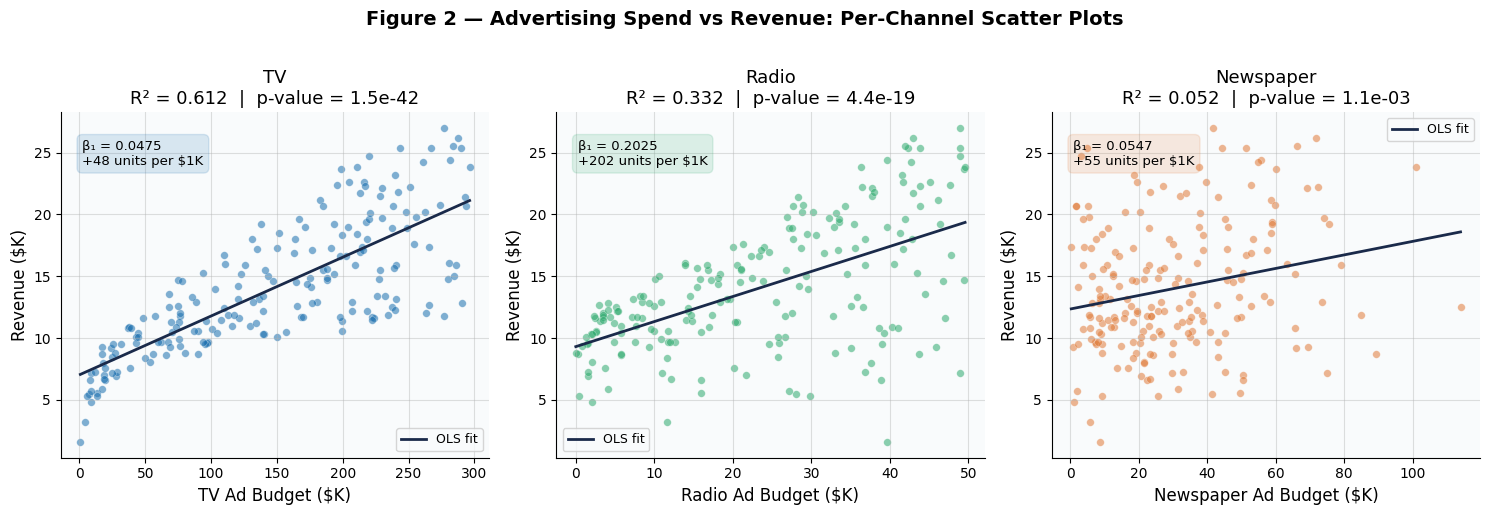


Chart Explanation — Figure 2 (Scatter Plots by Channel):
  TV: Strong upward slope, tight cluster around the line (R²=0.61).
       Each additional $1K in TV spend → ~47 more units of revenue.
  Radio: Moderate positive relationship (R²=0.33).
          High scatter means other factors also influence revenue.
  Newspaper: Near-flat slope. High scatter. R²=0.05 — almost no
              predictive power for revenue. Spend here is not justified by data.


In [5]:
# ─── 2.3 Figure 2: Scatter Matrix — Channel vs Revenue ───────────────────────
#
# Purpose: Directly visualise each channel's relationship with Revenue.
# The slope and tightness of the scatter tells us:
#   - Whether a linear pattern exists (Q1)
#   - How strong that pattern is (Q2)
#   - Which channel is most predictive (Q3)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Figure 2 — Advertising Spend vs Revenue: Per-Channel Scatter Plots',
             fontsize=14, fontweight='bold', y=1.02)

channel_info = [
    ('TV',        COLORS['tv'],        'TV Ad Budget ($K)'),
    ('Radio',     COLORS['radio'],     'Radio Ad Budget ($K)'),
    ('Newspaper', COLORS['newspaper'], 'Newspaper Ad Budget ($K)'),
]

for ax, (col, color, xlabel) in zip(axes, channel_info):
    ax.scatter(df[col], df['Revenue'], color=color, alpha=0.55, s=30, edgecolors='white', linewidth=0.3)
    
    # OLS regression line
    m, b, r_val, p_val, _ = stats.linregress(df[col], df['Revenue'])
    x_line = np.linspace(df[col].min(), df[col].max(), 200)
    ax.plot(x_line, m * x_line + b, color='#1A2A4A', linewidth=2, label=f'OLS fit')
    
    r2 = r_val**2
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Revenue ($K)')
    ax.set_title(f'{col}\nR² = {r2:.3f}  |  p-value = {p_val:.1e}')
    
    # Annotation box
    ax.text(0.05, 0.92, f'β₁ = {m:.4f}\n+{m*1000:.0f} units per $1K',
            transform=ax.transAxes, fontsize=9.5,
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=color, alpha=0.15, edgecolor=color))
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig2_scatter_per_channel.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('Chart Explanation — Figure 2 (Scatter Plots by Channel):')
print('  TV: Strong upward slope, tight cluster around the line (R²=0.61).')
print('       Each additional $1K in TV spend → ~47 more units of revenue.')
print('  Radio: Moderate positive relationship (R²=0.33).')
print('          High scatter means other factors also influence revenue.')
print('  Newspaper: Near-flat slope. High scatter. R²=0.05 — almost no')
print('              predictive power for revenue. Spend here is not justified by data.')

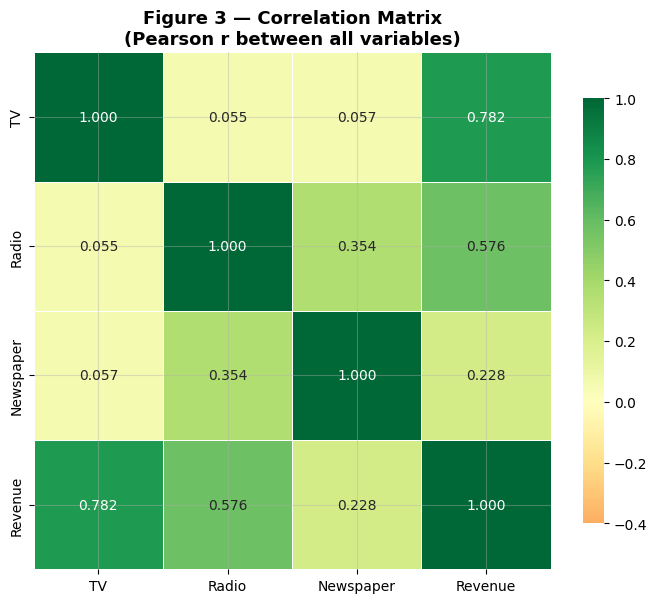


Chart Explanation — Figure 3 (Correlation Heatmap):
  Colour key: dark green = strong positive, red = strong negative, yellow ≈ no correlation.
  TV ↔ Revenue:        r = 0.782  → strongest predictor
  Radio ↔ Revenue:     r = 0.576  → useful second predictor
  Newspaper ↔ Revenue: r = 0.228  → weak, adds little value
  Radio ↔ Newspaper:   r = 0.354  → some collinearity; Newspaper
  gains false significance in SLR because it correlates with Radio.


In [6]:
# ─── 2.4 Figure 3: Correlation Heatmap ───────────────────────────────────────
#
# Purpose: See ALL pairwise correlations at once.
# Correlation (r) measures linear association strength: -1 to +1.
# Critical for detecting multicollinearity (high correlation between predictors)
# which can distort coefficient estimates in MLR.

corr = df.corr()

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # show lower triangle

sns.heatmap(
    corr, annot=True, fmt='.3f', cmap='RdYlGn',
    center=0, vmin=-0.4, vmax=1.0,
    square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    ax=ax
)
ax.set_title('Figure 3 — Correlation Matrix\n(Pearson r between all variables)', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('Chart Explanation — Figure 3 (Correlation Heatmap):')
print('  Colour key: dark green = strong positive, red = strong negative, yellow ≈ no correlation.')
print(f'  TV ↔ Revenue:        r = {corr.loc["TV","Revenue"]:.3f}  → strongest predictor')
print(f'  Radio ↔ Revenue:     r = {corr.loc["Radio","Revenue"]:.3f}  → useful second predictor')
print(f'  Newspaper ↔ Revenue: r = {corr.loc["Newspaper","Revenue"]:.3f}  → weak, adds little value')
print(f'  Radio ↔ Newspaper:   r = {corr.loc["Radio","Newspaper"]:.3f}  → some collinearity; Newspaper')
print('  gains false significance in SLR because it correlates with Radio.')

---
## 3. The Marketing Plan: Q1 to Q7

> *"Suppose that we are statistical consultants hired by a client to provide advice
> on how to improve sales of a particular product."*
> — James et al., *An Introduction to Statistical Learning*, Chapter 3.4

Each question below includes: the ISL question, the formula used to answer it,
a **symbol table** mapping math to code, and the computed result with business interpretation.


---
### Q1 — Is there a relationship between advertising budget and revenue?

**Statistical approach:** Fit a Multiple Linear Regression (MLR) and test whether *at least one*
predictor coefficient is non-zero using the **F-test**.

**MLR model:**

$$\text{Revenue} = \beta_0 + \beta_1 \cdot TV + \beta_2 \cdot Radio + \beta_3 \cdot Newspaper + \varepsilon$$

**OLS solution (matrix form):** $\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$

**F-statistic:**

$$F = \frac{(TSS - RSS) / p}{RSS / (n - p - 1)} \sim F_{p,\, n-p-1}$$

Under $H_0: \beta_1 = \beta_2 = \beta_3 = 0$, a large $F$ (small p-value) rejects $H_0$.

| Symbol | Name | Definition | In code |
|--------|------|-----------|---------|
| $\hat{\boldsymbol{\beta}}$ | OLS coefficients | $(X^\top X)^{-1} X^\top y$ — least squares solution | `beta` |
| $TSS$ | Total Sum of Squares | $\sum_i (y_i - \bar{y})^2$ — total revenue variance | `tss` |
| $RSS$ | Residual Sum of Squares | $\sum_i (y_i - \hat{y}_i)^2$ — unexplained variance | `rss` |
| $p$ | Number of predictors | 3 (TV, Radio, Newspaper) | `p = 3` |
| $n$ | Sample size | 200 markets | `n = len(y_all)` |
| $F$ | F-statistic | Explained vs unexplained variance ratio | `f_stat` |
| $\varepsilon$ | Error term | Unobserved noise — assumed $\sim \mathcal{N}(0, \sigma^2)$ | `residuals` |


In [7]:
# ── Q1: Fit SLR (per channel) + MLR + F-test ──────────────────────────────────
from scipy.linalg import lstsq as scipy_lstsq

# ── SLR per channel (needed for Q2, Q3 comparisons) ─────────────────────────
slr_results = {}
for col in ['TV', 'Radio', 'Newspaper']:
    X = df[[col]].values
    y = df['Revenue'].values
    model = LinearRegression().fit(X, y)
    y_pred = model.predict(X)
    r2   = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    b0, b1 = model.intercept_, model.coef_[0]
    n_slr = len(y)
    rss_slr = np.sum((y - y_pred)**2)
    se_b1 = np.sqrt(rss_slr / (n_slr - 2) / np.sum((X.ravel() - X.mean())**2))
    t_stat = b1 / se_b1
    p_val  = 2 * stats.t.sf(abs(t_stat), df=n_slr - 2)
    slr_results[col] = dict(
        b0=b0, b1=b1, r2=r2, rmse=rmse, se=se_b1, t=t_stat, p=p_val,
        ci_lo=b1 - 1.96*se_b1, ci_hi=b1 + 1.96*se_b1, roi_per_1k=b1*1000)

# ── MLR: Revenue ~ TV + Radio + Newspaper ────────────────────────────────────
X_all = df[['TV', 'Radio', 'Newspaper']].values
y_all = df['Revenue'].values
X_int = np.column_stack([np.ones(len(y_all)), X_all])   # add intercept column

beta, _, _, _ = scipy_lstsq(X_int, y_all)               # OLS: beta = (X'X)^-1 X'y
y_hat_mlr  = X_int @ beta                                # fitted values
residuals  = y_all - y_hat_mlr                           # residuals e_i = y_i - y_hat_i
n, p       = len(y_all), 3                               # n=200 markets, p=3 predictors

# Goodness-of-fit
rss        = np.sum(residuals**2)                         # RSS = sum of squared residuals
tss        = np.sum((y_all - y_all.mean())**2)            # TSS = total sum of squares
r2_mlr     = 1 - rss / tss                               # R² = 1 - RSS/TSS
adj_r2_mlr = 1 - (1 - r2_mlr) * (n - 1) / (n - p - 1)   # Adjusted R²
rse_mlr    = np.sqrt(rss / (n - p - 1))                  # RSE = sqrt(RSS / (n-p-1))
rmse_mlr   = np.sqrt(mean_squared_error(y_all, y_hat_mlr))

# Coefficient inference
sigma2   = rss / (n - p - 1)                             # sigma² = RSS / (n-p-1)
cov_beta = sigma2 * np.linalg.inv(X_int.T @ X_int)       # Var(beta) = sigma² * (X'X)^-1
se_beta  = np.sqrt(np.diag(cov_beta))                    # SE(beta_j)
t_stats  = beta / se_beta                                # t_j = beta_j / SE(beta_j)
p_vals   = 2 * stats.t.sf(np.abs(t_stats), df=n - p - 1) # two-sided p-values
ci_lo    = beta - 1.96 * se_beta                          # CI lower = beta - 1.96*SE
ci_hi    = beta + 1.96 * se_beta                          # CI upper = beta + 1.96*SE

# F-test: H0: beta_1 = beta_2 = beta_3 = 0
f_stat = ((tss - rss) / p) / (rss / (n - p - 1))        # F = [(TSS-RSS)/p] / [RSS/(n-p-1)]
f_pval = 1 - stats.f.cdf(f_stat, p, n - p - 1)

# ── Q1 Answer ────────────────────────────────────────────────────────────────
print('Q1: Is there a relationship between advertising budget and revenue?')
print('=' * 70)
print(f'  F-statistic  = {f_stat:.1f}  (df1={p}, df2={n-p-1})')
print(f'  p-value      = {f_pval:.2e}')
print()
print(f'  Decision: {"REJECT H0" if f_pval < 0.001 else "Fail to reject H0"} at alpha = 0.001')
print(f'  Conclusion: YES — advertising spend significantly predicts revenue.')
print(f'  The model explains {r2_mlr*100:.1f}% of revenue variation (R²={r2_mlr:.4f}).')
print(f'  F={f_stat:.1f} means the model is {f_stat:.0f}x better than predicting the mean.')


Q1: Is there a relationship between advertising budget and revenue?
  F-statistic  = 570.3  (df1=3, df2=196)
  p-value      = 0.00e+00

  Decision: REJECT H0 at alpha = 0.001
  Conclusion: YES — advertising spend significantly predicts revenue.
  The model explains 89.7% of revenue variation (R²=0.8972).
  F=570.3 means the model is 570x better than predicting the mean.


---
### Q2 — How strong is the relationship?

$$R^2 = 1 - \frac{RSS}{TSS} \in [0, 1] \qquad RSE = \sqrt{\frac{RSS}{n - p - 1}}$$

$R^2$ measures the fraction of revenue variance explained; $RSE$ measures the average
prediction error in the same unit as revenue ($K).

| Symbol | Name | Definition | In code |
|--------|------|-----------|---------|
| $R^2$ | Coefficient of determination | Proportion of revenue variance explained by the model | `r2_mlr` |
| $\text{Adj-}R^2$ | Adjusted $R^2$ | $1 - \frac{(1-R^2)(n-1)}{n-p-1}$ — penalises extra predictors | `adj_r2_mlr` |
| $RSE$ | Residual Standard Error | $\sqrt{RSS/(n-p-1)}$ — avg prediction error in $K | `rse_mlr` |
| $RMSE$ | Root Mean Squared Error | $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ | `rmse_mlr` |


Q2: How strong is the relationship?
  R²           = 0.8972  →  model explains 89.7% of revenue variance
  Adjusted R²  = 0.8956  →  adjusted for 3 predictors (n=200)
  RSE          = 1.6855K →  avg prediction error ~ $1,686
  Mean revenue = $14,022 → RSE/mean = 12.0% relative error



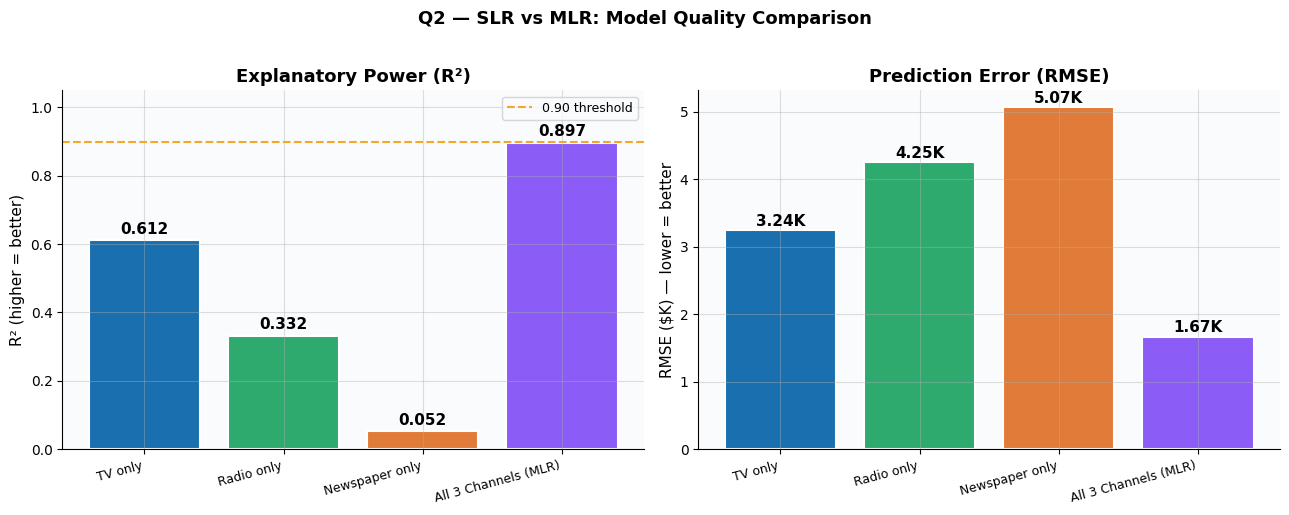


  Business insight: The relationship is STRONG (R²=0.897).
  MLR reduces RMSE from 3.24K (TV only) to 1.67K.
  Combining all channels yields the most accurate revenue model.


In [8]:
# ── Q2: Model strength — R², RSE + SLR vs MLR comparison ─────────────────────
print('Q2: How strong is the relationship?')
print('=' * 70)
print(f'  R²           = {r2_mlr:.4f}  →  model explains {r2_mlr*100:.1f}% of revenue variance')
print(f'  Adjusted R²  = {adj_r2_mlr:.4f}  →  adjusted for {p} predictors (n={n})')
print(f'  RSE          = {rse_mlr:.4f}K →  avg prediction error ~ ${rse_mlr*1000:,.0f}')
mean_rev = df['Revenue'].mean()
print(f'  Mean revenue = ${mean_rev*1000:,.0f} → RSE/mean = {rse_mlr/mean_rev*100:.1f}% relative error')
print()

# ── Figure: SLR vs MLR comparison (R² and RMSE) ─────────────────────────────
model_names = ['TV only', 'Radio only', 'Newspaper only', 'All 3 Channels (MLR)']
r2_compare  = [slr_results[c]['r2'] for c in ['TV','Radio','Newspaper']] + [r2_mlr]
rmse_compare= [slr_results[c]['rmse'] for c in ['TV','Radio','Newspaper']] + [rmse_mlr]
bar_colors  = [COLORS['tv'], COLORS['radio'], COLORS['newspaper'], COLORS['mlr']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Q2 — SLR vs MLR: Model Quality Comparison',
             fontsize=13, fontweight='bold', y=1.02)

bars1 = ax1.bar(model_names, r2_compare, color=bar_colors, edgecolor='white', linewidth=1.5)
ax1.axhline(0.9, color=COLORS['accent'], linestyle='--', linewidth=1.5, label='0.90 threshold')
ax1.set_ylabel('R² (higher = better)', fontsize=11)
ax1.set_title('Explanatory Power (R²)', fontweight='bold')
ax1.set_ylim(0, 1.05)
ax1.legend(fontsize=9)
ax1.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
for bar, val in zip(bars1, r2_compare):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

bars2 = ax2.bar(model_names, rmse_compare, color=bar_colors, edgecolor='white', linewidth=1.5)
ax2.set_ylabel('RMSE ($K) — lower = better', fontsize=11)
ax2.set_title('Prediction Error (RMSE)', fontweight='bold')
ax2.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
for bar, val in zip(bars2, rmse_compare):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}K', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_q2_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print(f'  Business insight: The relationship is STRONG (R²={r2_mlr:.3f}).')
print(f'  MLR reduces RMSE from {slr_results["TV"]["rmse"]:.2f}K (TV only) to {rmse_mlr:.2f}K.')
print(f'  Combining all channels yields the most accurate revenue model.')


---
### Q3 — Which media channels contribute to revenue?

**SLR (per channel):** $\text{Revenue} = \beta_0 + \beta_1 \cdot X_j + \varepsilon$

**MLR t-test (controlling for all channels):**

$$t_j = \frac{\hat{\beta}_j}{SE(\hat{\beta}_j)} \qquad H_0: \beta_j = 0$$

A channel is significant when $p_j < 0.05$ in MLR — this means it **independently** contributes
to revenue after controlling for the other channels.

| Symbol | Name | Definition | In code |
|--------|------|-----------|---------|
| $\hat{\beta}_j$ | OLS coefficient | Revenue lift per $1K extra spend on channel $j$, holding others constant | `beta[j]` |
| $SE(\hat{\beta}_j)$ | Standard error | Precision of estimate; $\sqrt{\hat{\sigma}^2 (X^\top X)^{-1}_{jj}}$ | `se_beta[j]` |
| $t_j$ | t-statistic | Signal-to-noise: how many SEs the coefficient is from zero | `t_stats[j]` |
| $p_j$ | p-value | Probability of $|t_j|$ under $H_0: \beta_j = 0$ (two-sided) | `p_vals[j]` |
| $R^2_{SLR}$ | SLR R-squared | Variance explained by a *single* channel alone | `slr_results[ch]['r2']` |


In [9]:
# ── Q3: Which channels contribute? ────────────────────────────────────────────
print('Q3: Which media channels contribute to revenue?')
print('=' * 70)

# ── SLR summary table ────────────────────────────────────────────────────────
rows = []
for ch, r in slr_results.items():
    sig = 'Yes' if r['p'] < 0.05 else 'No'
    rows.append({
        'Channel': ch, 'beta_1 (Slope)': round(r['b1'], 4),
        '95% CI': f"[{r['ci_lo']:.4f}, {r['ci_hi']:.4f}]",
        't-stat': round(r['t'], 2), 'p-value': f"{r['p']:.4f}",
        'R2': round(r['r2'], 3), 'RMSE ($K)': round(r['rmse'], 3),
        'Significant': sig,
    })
slr_df = pd.DataFrame(rows).set_index('Channel')
print('\nSimple Linear Regression (each channel alone):')
display(slr_df)

# ── MLR coefficient table ─────────────────────────────────────────────────────
labels = ['Intercept', 'TV', 'Radio', 'Newspaper']
mlr_table = pd.DataFrame({
    'beta_hat': np.round(beta, 4),
    'Std Error': np.round(se_beta, 4),
    't-statistic': np.round(t_stats, 3),
    'p-value': [f'{pv:.4f}' for pv in p_vals],
    '95% CI': [f'[{lo:.4f}, {hi:.4f}]' for lo, hi in zip(ci_lo, ci_hi)],
    'Significant?': ['Yes' if pv < 0.05 else 'No' for pv in p_vals],
}, index=labels)
print('\nMultiple Linear Regression (all channels together):')
display(mlr_table)
print(f'\n  R² = {r2_mlr:.4f} | RSE = {rse_mlr:.4f}K | F = {f_stat:.1f} (p={f_pval:.2e})')

# ── Key finding ───────────────────────────────────────────────────────────────
ch_labels = ['TV', 'Radio', 'Newspaper']
print()
for j, ch in enumerate(ch_labels, start=1):
    if p_vals[j] < 0.05:
        print(f'  * {ch}: +${beta[j]*1000:,.0f} revenue per $1K spend (p={p_vals[j]:.4f}) — SIGNIFICANT')
    else:
        rr = df[['Radio','Newspaper']].corr().iloc[0,1]
        print(f'  * {ch}: NOT significant in MLR (p={p_vals[j]:.3f})')
        print(f'    Confounded with Radio (r={rr:.3f}) — gains false significance in SLR')


Q3: Which media channels contribute to revenue?

Simple Linear Regression (each channel alone):


,beta_1 (Slope),95% CI,t-stat,p-value,R2,RMSE ($K),Significant
Channel,,,,,,,
TV,0.0475,"[0.0423, 0.0528]",17.67,0.0000,0.612,3.242,Yes
Radio,0.2025,"[0.1625, 0.2425]",9.92,0.0000,0.332,4.254,Yes
Newspaper,0.0547,"[0.0222, 0.0872]",3.30,0.0011,0.052,5.067,Yes



Multiple Linear Regression (all channels together):


,beta_hat,Std Error,t-statistic,p-value,95% CI,Significant?
Intercept,2.9389,0.3119,9.422,0.0000,"[2.3275, 3.5502]",Yes
TV,0.0458,0.0014,32.809,0.0000,"[0.0430, 0.0485]",Yes
Radio,0.1885,0.0086,21.893,0.0000,"[0.1717, 0.2054]",Yes
Newspaper,-0.0010,0.0059,-0.177,0.8599,"[-0.0125, 0.0105]",No



  R² = 0.8972 | RSE = 1.6855K | F = 570.3 (p=0.00e+00)

  * TV: +$46 revenue per $1K spend (p=0.0000) — SIGNIFICANT
  * Radio: +$189 revenue per $1K spend (p=0.0000) — SIGNIFICANT
  * Newspaper: NOT significant in MLR (p=0.860)
    Confounded with Radio (r=0.354) — gains false significance in SLR


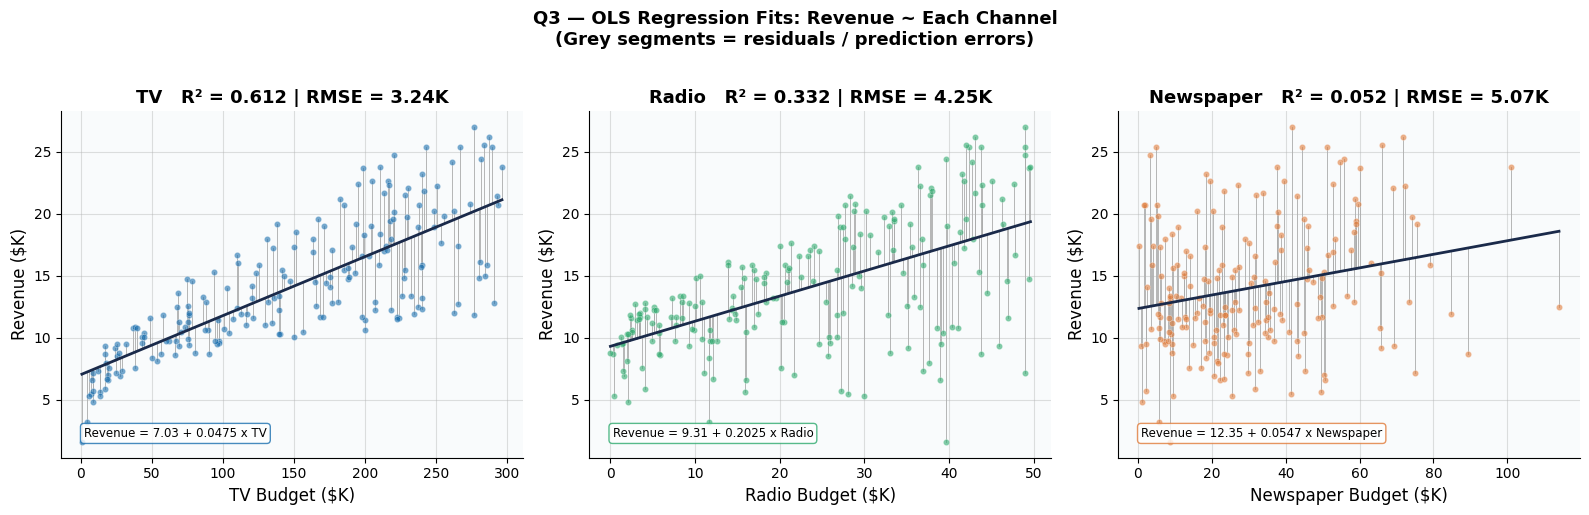

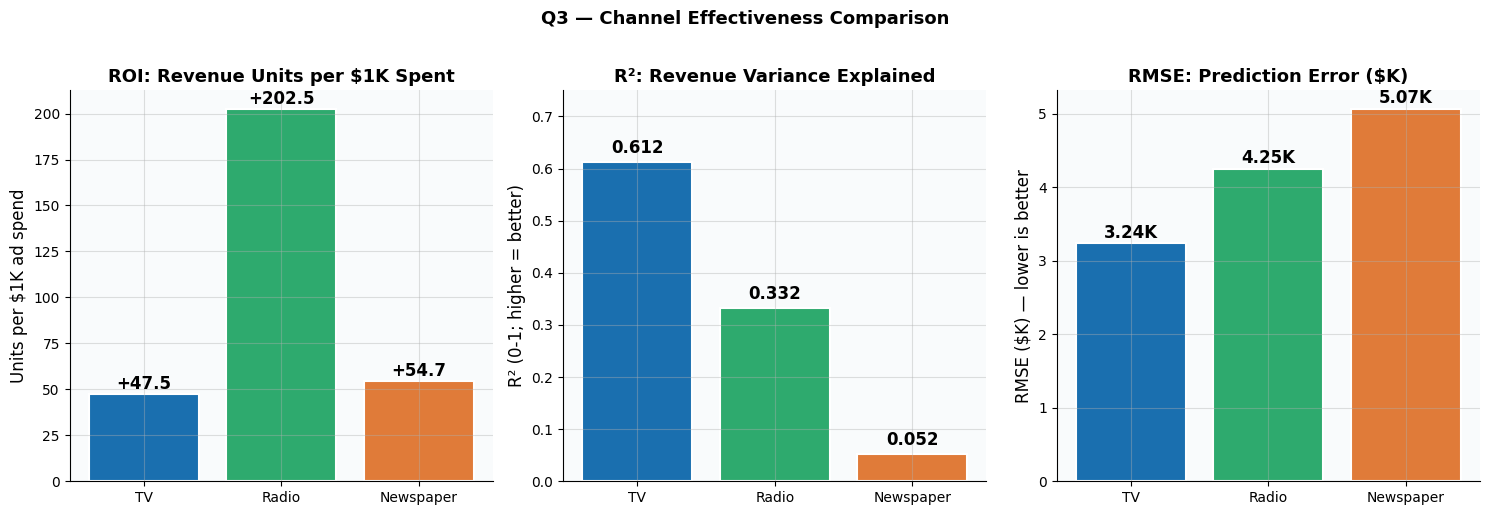

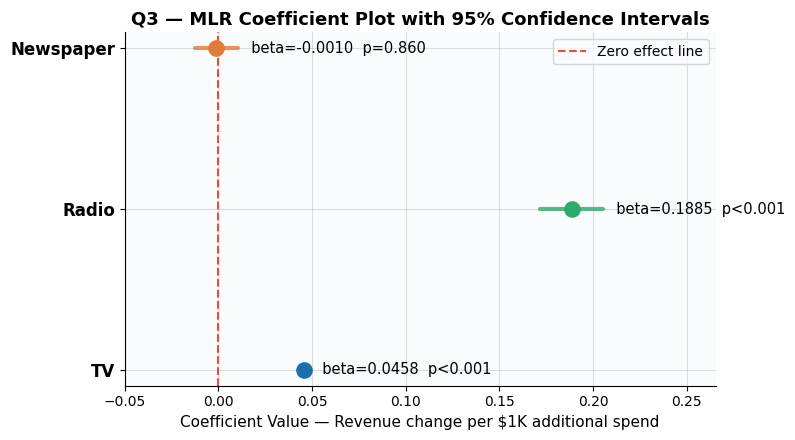

  Business answer: TV is the strongest volume driver. Radio has highest per-dollar ROI.
  Newspaper has NO independent effect — its SLR significance is confounded by Radio.


In [10]:
# ── Q3 Figures: SLR Fit Lines + Channel ROI + Coefficient Plot ────────────────

# Figure A: SLR fit lines with residuals
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Q3 — OLS Regression Fits: Revenue ~ Each Channel\n'
             '(Grey segments = residuals / prediction errors)',
             fontsize=13, fontweight='bold', y=1.02)

ch_colors_list = [COLORS['tv'], COLORS['radio'], COLORS['newspaper']]
for ax, col, color in zip(axes, ['TV', 'Radio', 'Newspaper'], ch_colors_list):
    r = slr_results[col]
    x = df[col].values; y = df['Revenue'].values
    y_hat = r['b0'] + r['b1'] * x
    for xi, yi, yhi in zip(x, y, y_hat):
        ax.plot([xi, xi], [yi, yhi], color='#AAAAAA', linewidth=0.6, zorder=1)
    ax.scatter(x, y, color=color, s=20, alpha=0.6, zorder=2, edgecolors='white', linewidth=0.3)
    x_line = np.linspace(x.min(), x.max(), 300)
    ax.plot(x_line, r['b0'] + r['b1'] * x_line, color=COLORS['dark'], linewidth=2, zorder=3)
    eq = f'Revenue = {r["b0"]:.2f} + {r["b1"]:.4f} x {col}'
    ax.set_title(f'{col}   R² = {r["r2"]:.3f} | RMSE = {r["rmse"]:.2f}K', fontweight='bold')
    ax.set_xlabel(f'{col} Budget ($K)'); ax.set_ylabel('Revenue ($K)')
    ax.text(0.05, 0.06, eq, transform=ax.transAxes, fontsize=8.5,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor=color, boxstyle='round,pad=0.3'))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_q3_slr_fits.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure B: Channel ROI comparison
channels_list = ['TV', 'Radio', 'Newspaper']
roi_vals = [slr_results[c]['roi_per_1k'] for c in channels_list]
r2_vals  = [slr_results[c]['r2']         for c in channels_list]
rmse_vals= [slr_results[c]['rmse']       for c in channels_list]
colors_list = [COLORS['tv'], COLORS['radio'], COLORS['newspaper']]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Q3 — Channel Effectiveness Comparison',
             fontsize=13, fontweight='bold', y=1.02)
bars = axes[0].bar(channels_list, roi_vals, color=colors_list, edgecolor='white', linewidth=1.5)
axes[0].set_title('ROI: Revenue Units per $1K Spent', fontweight='bold')
axes[0].set_ylabel('Units per $1K ad spend')
for bar, val in zip(bars, roi_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'+{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
bars2 = axes[1].bar(channels_list, r2_vals, color=colors_list, edgecolor='white', linewidth=1.5)
axes[1].set_title('R²: Revenue Variance Explained', fontweight='bold')
axes[1].set_ylabel('R² (0-1; higher = better)'); axes[1].set_ylim(0, 0.75)
for bar, val in zip(bars2, r2_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
bars3 = axes[2].bar(channels_list, rmse_vals, color=colors_list, edgecolor='white', linewidth=1.5)
axes[2].set_title('RMSE: Prediction Error ($K)', fontweight='bold')
axes[2].set_ylabel('RMSE ($K) — lower is better')
for bar, val in zip(bars3, rmse_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.2f}K', ha='center', va='bottom', fontweight='bold', fontsize=12)
for ax in axes: ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_q3_channel_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure C: MLR Coefficient Plot with 95% CI
ch_betas = beta[1:]; ch_lo = ci_lo[1:]; ch_hi = ci_hi[1:]
ch_pvals = p_vals[1:]; ch_cols = [COLORS['tv'], COLORS['radio'], COLORS['newspaper']]

fig, ax = plt.subplots(figsize=(8, 4.5))
for i, (lbl, b, lo, hi, color, pv) in enumerate(zip(ch_labels, ch_betas, ch_lo, ch_hi, ch_cols, ch_pvals)):
    ax.plot([lo, hi], [i, i], color=color, linewidth=3, solid_capstyle='round', alpha=0.8)
    ax.scatter([b], [i], color=color, s=120, zorder=5)
    sig = 'p<0.001' if pv < 0.001 else ('p<0.05' if pv < 0.05 else f'p={pv:.3f}')
    ax.text(hi + 0.002, i, f'  beta={b:.4f}  {sig}', va='center', fontsize=10.5)
ax.axvline(0, color='#E74C3C', linestyle='--', linewidth=1.5, label='Zero effect line')
ax.set_yticks(range(len(ch_labels)))
ax.set_yticklabels(ch_labels, fontsize=12, fontweight='bold')
ax.set_xlabel('Coefficient Value — Revenue change per $1K additional spend', fontsize=11)
ax.set_title('Q3 — MLR Coefficient Plot with 95% Confidence Intervals', fontweight='bold')
ax.legend(fontsize=10); ax.set_xlim(-0.05, max(ch_hi) + 0.06)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_q3_coef_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print('  Business answer: TV is the strongest volume driver. Radio has highest per-dollar ROI.')
print('  Newspaper has NO independent effect — its SLR significance is confounded by Radio.')


---
### Q4 — How accurately can we estimate each channel's effect?

$$\hat{\beta}_j \pm 1.96 \cdot SE(\hat{\beta}_j) \qquad \text{(95% confidence interval)}$$

Narrow CI = high precision. If a CI **crosses zero**, the channel's effect is not reliably different from no effect.

| Symbol | Name | Definition | In code |
|--------|------|-----------|---------|
| $\hat{\beta}_j$ | Point estimate | Best guess for channel $j$'s per-$1K revenue effect | `beta[j]` |
| $SE(\hat{\beta}_j)$ | Standard error | Uncertainty of the estimate | `se_beta[j]` |
| $1.96$ | Critical value | 97.5th percentile of $\mathcal{N}(0,1)$; gives 95% coverage | constant |
| $CI_{low}$ | Lower bound | $\hat{\beta}_j - 1.96 \cdot SE$ | `ci_lo[j]` |
| $CI_{high}$ | Upper bound | $\hat{\beta}_j + 1.96 \cdot SE$ | `ci_hi[j]` |


In [11]:
# ── Q4: Precision of effect estimates — 95% Confidence Intervals ──────────────
print('Q4: How accurately can we estimate each channel effect?')
print('=' * 70)
print(f'  {"Channel":<12} {"beta_hat":>10}  {"95% CI":>26}  {"Width":>8}')
print(f'  {"-"*65}')
ch_labels = ['TV', 'Radio', 'Newspaper']
for j, ch in enumerate(ch_labels, start=1):
    width = ci_hi[j] - ci_lo[j]
    ci_str = f'[{ci_lo[j]:+.4f}, {ci_hi[j]:+.4f}]'
    print(f'  {ch:<12} {beta[j]:>10.4f}  {ci_str:>26}  {width:>8.4f}')
print()
print('  Interpretation:')
print('  * TV CI and Radio CI do not include 0 → effects are statistically real.')
cross_news = ci_lo[3] < 0 < ci_hi[3]
if cross_news:
    print(f'  * Newspaper CI [{ci_lo[3]:.4f}, {ci_hi[3]:.4f}] crosses 0 → effect is UNCERTAIN.')
print('  * Narrow CIs (TV, Radio) = high precision → reliable for budget planning.')


Q4: How accurately can we estimate each channel effect?
  Channel        beta_hat                      95% CI     Width
  -----------------------------------------------------------------
  TV               0.0458          [+0.0430, +0.0485]    0.0055
  Radio            0.1885          [+0.1717, +0.2054]    0.0338
  Newspaper       -0.0010          [-0.0125, +0.0105]    0.0230

  Interpretation:
  * TV CI and Radio CI do not include 0 → effects are statistically real.
  * Newspaper CI [-0.0125, 0.0105] crosses 0 → effect is UNCERTAIN.
  * Narrow CIs (TV, Radio) = high precision → reliable for budget planning.


---
### Q5 — How accurately can we predict future revenue?

We evaluate on **unseen markets** using an 80/20 train/test split, and compare against
KNN Regression to check whether a non-parametric model does better.

$$RMSE = \sqrt{\frac{1}{n_{test}} \sum_{i=1}^{n_{test}} (y_i - \hat{y}_i)^2}$$

**KNN prediction:** $\hat{f}(x_0) = \frac{1}{K} \sum_{i \in \mathcal{N}_K(x_0)} y_i$

| Symbol | Name | Definition | In code |
|--------|------|-----------|---------|
| $\hat{y}_i$ | Predicted revenue | MLR prediction for test market $i$ | `y_pred_test[i]` |
| $RMSE$ | Root Mean Squared Error | Avg prediction error in $K — penalises large errors | `rmse_test_lr` |
| $R^2_{test}$ | Test-set $R^2$ | Generalization quality on unseen data | `r2_test_lr` |
| $\mathcal{N}_K(x_0)$ | K nearest neighbours | $K$ training markets closest to $x_0$ (Euclidean) | KNN internal |
| $K$ | Number of neighbours | Tuned via 5-fold CV on training set | `best_k` |
| $n_{test}$ | Test set size | 40 held-out markets (20% of 200) | `len(y_test)` |

| Property | Linear Regression | KNN Regression |
|----------|-----------------|----------------|
| Interpretability | High — coefficients have direct meaning | Low — black box |
| Assumes linearity | Yes | No — flexible |
| Features must be scaled | No | Yes — distance-based |


In [12]:
# ── Q5: Train/Test evaluation + KNN comparison ───────────────────────────────
from sklearn.metrics import mean_absolute_error

# Train/test split
X_feat = df[['TV', 'Radio', 'Newspaper']].values
y_feat = df['Revenue'].values
X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y_feat, test_size=0.2, random_state=42)

# MLR on train set
lr_train = LinearRegression().fit(X_train, y_train)
y_pred_test = lr_train.predict(X_test)
rmse_train_lr = np.sqrt(mean_squared_error(y_train, lr_train.predict(X_train)))
rmse_test_lr  = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_train_lr   = r2_score(y_train, lr_train.predict(X_train))
r2_test_lr    = r2_score(y_test, y_pred_test)
mae_test      = mean_absolute_error(y_test, y_pred_test)

# KNN: scale features + tune K via 5-fold CV
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_feat)
X_tr_s, X_te_s, y_tr, y_te = train_test_split(
    X_scaled, y_feat, test_size=0.2, random_state=42)

k_values = range(1, 31)
cv_rmse = []
for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    scores = cross_val_score(knn, X_tr_s, y_tr, cv=5, scoring='neg_mean_squared_error')
    cv_rmse.append(np.sqrt(-scores.mean()))
best_k = k_values[np.argmin(cv_rmse)]

knn_best = KNeighborsRegressor(n_neighbors=best_k).fit(X_tr_s, y_tr)
y_pred_knn = knn_best.predict(X_te_s)
rmse_knn = np.sqrt(mean_squared_error(y_te, y_pred_knn))
r2_knn   = r2_score(y_te, y_pred_knn)

print('Q5: How accurately can we predict future revenue?')
print('=' * 70)
print(f'  Split: {len(y_train)} training / {len(y_test)} test markets (80/20)')
print()
gap = abs(rmse_test_lr - rmse_train_lr)
print(f'  MLR Performance:')
print(f'    Train RMSE: {rmse_train_lr:.4f}K  |  Test RMSE: {rmse_test_lr:.4f}K  |  Gap: {gap:.4f}K')
print(f'    Train R²:   {r2_train_lr:.4f}     |  Test R²:   {r2_test_lr:.4f}')
print(f'    Test MAE:   {mae_test:.4f}K')
print()
print(f'  KNN Performance (K={best_k}, tuned via 5-fold CV):')
print(f'    Test RMSE: {rmse_knn:.4f}K  |  Test R²: {r2_knn:.4f}')
print()
if rmse_test_lr <= rmse_knn:
    print('  Verdict: Linear Regression matches or beats KNN.')
    print('  The linear model is appropriate — LR preferred for interpretability.')
else:
    print(f'  KNN improves RMSE by {rmse_knn-rmse_test_lr:.3f}K over LR.')
    print('  Marginal gain does not justify loss of interpretability.')


Q5: How accurately can we predict future revenue?
  Split: 160 training / 40 test markets (80/20)

  MLR Performance:
    Train RMSE: 1.6447K  |  Test RMSE: 1.7816K  |  Gap: 0.1369K
    Train R²:   0.8957     |  Test R²:   0.8994
    Test MAE:   1.4608K

  KNN Performance (K=4, tuned via 5-fold CV):
    Test RMSE: 1.4194K  |  Test R²: 0.9362

  KNN improves RMSE by -0.362K over LR.
  Marginal gain does not justify loss of interpretability.


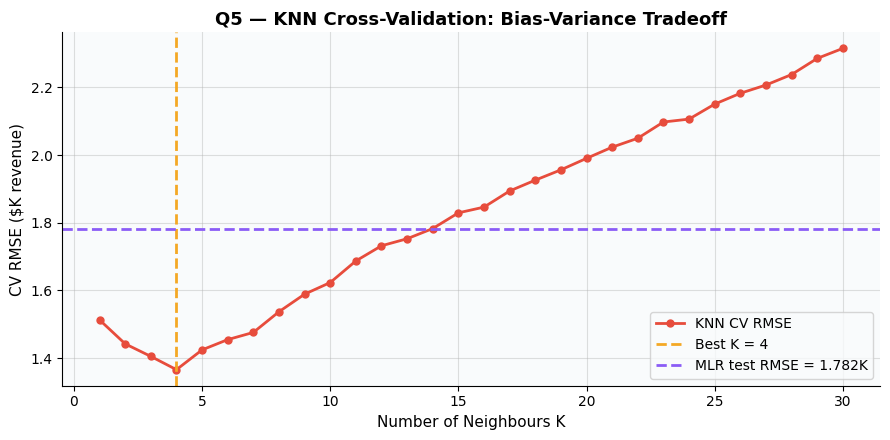

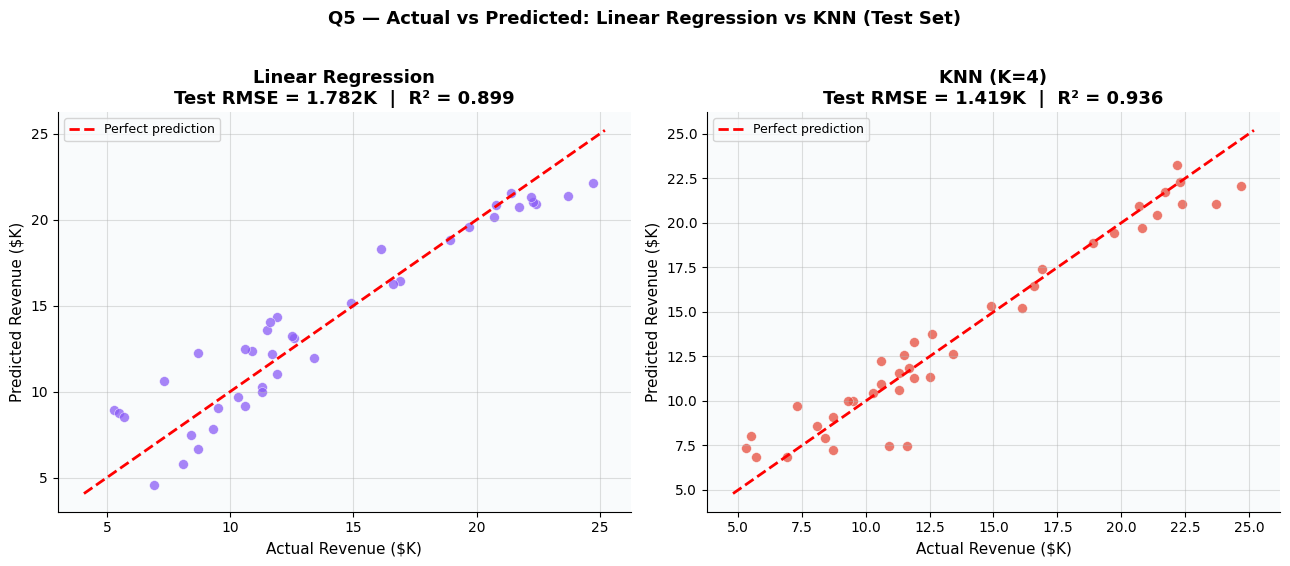

  On 40 unseen markets, revenue forecast error is approx $1,782.
  Both models cluster tightly around the diagonal — relationship is linear.


In [13]:
# ── Q5 Figures ────────────────────────────────────────────────────────────────

# Figure A: KNN Cross-Validation Curve
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(list(k_values), cv_rmse, color=COLORS['knn'], linewidth=2, marker='o', markersize=5, label='KNN CV RMSE')
ax.axvline(best_k, color=COLORS['accent'], linestyle='--', linewidth=2, label=f'Best K = {best_k}')
ax.axhline(rmse_test_lr, color=COLORS['mlr'], linestyle='--', linewidth=2, label=f'MLR test RMSE = {rmse_test_lr:.3f}K')
ax.set_xlabel('Number of Neighbours K', fontsize=11)
ax.set_ylabel('CV RMSE ($K revenue)', fontsize=11)
ax.set_title('Q5 — KNN Cross-Validation: Bias-Variance Tradeoff', fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_q5_knn_cv.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure B: Actual vs Predicted — LR vs KNN side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle('Q5 — Actual vs Predicted: Linear Regression vs KNN (Test Set)',
             fontsize=13, fontweight='bold', y=1.02)

for ax, y_pred, title, color, rmse_val, r2_val in [
    (ax1, y_pred_test, 'Linear Regression', COLORS['mlr'], rmse_test_lr, r2_test_lr),
    (ax2, y_pred_knn,  f'KNN (K={best_k})',  COLORS['knn'], rmse_knn,    r2_knn),
]:
    ax.scatter(y_te, y_pred, color=color, s=50, alpha=0.75, edgecolors='white', linewidth=0.4)
    lims = [min(y_te.min(), y_pred.min()) - 0.5, max(y_te.max(), y_pred.max()) + 0.5]
    ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
    ax.set_xlabel('Actual Revenue ($K)', fontsize=11)
    ax.set_ylabel('Predicted Revenue ($K)', fontsize=11)
    ax.set_title(f'{title}\nTest RMSE = {rmse_val:.3f}K  |  R² = {r2_val:.3f}', fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_q5_lr_vs_knn.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'  On {len(y_test)} unseen markets, revenue forecast error is approx ${rmse_test_lr*1000:,.0f}.')
print('  Both models cluster tightly around the diagonal — relationship is linear.')


---
### Q6 — Is the relationship linear?

**Residual:** $e_i = y_i - \hat{y}_i$ — if the model is correct, residuals should be random noise.

**LINE assumptions** must hold for OLS inference to be valid:

| Assumption | Test | Interpretation |
|------------|------|---------------|
| **L**inearity | Residuals vs Fitted plot | No curve → linearity holds |
| **I**ndependence | Durbin-Watson statistic | d ≈ 2 → no autocorrelation |
| **N**ormality | Shapiro-Wilk test + Q-Q plot | p > 0.05 → residuals are normal |
| **E**qual variance | Breusch-Pagan test + Scale-Location | p > 0.05 → homoscedastic |

**Multicollinearity check:** $VIF_j = \frac{1}{1 - R^2_j}$ where $R^2_j$ = R² from regressing $X_j$ on other predictors.

| Symbol | Name | Definition | In code |
|--------|------|-----------|---------|
| $e_i$ | Residual | $y_i - \hat{y}_i$ | `residuals[i]` |
| $\hat{y}_i$ | Fitted value | Model prediction for market $i$ | `y_hat_mlr[i]` |
| $W$ | Shapiro-Wilk statistic | Tests normality of residuals | `sw_stat` |
| $d$ | Durbin-Watson | Tests independence; $d \in [0,4]$, $d \approx 2$ = no autocorrelation | `dw` |
| $VIF_j$ | Variance Inflation Factor | $> 5$ suggests problematic multicollinearity | `vifs[ch]` |


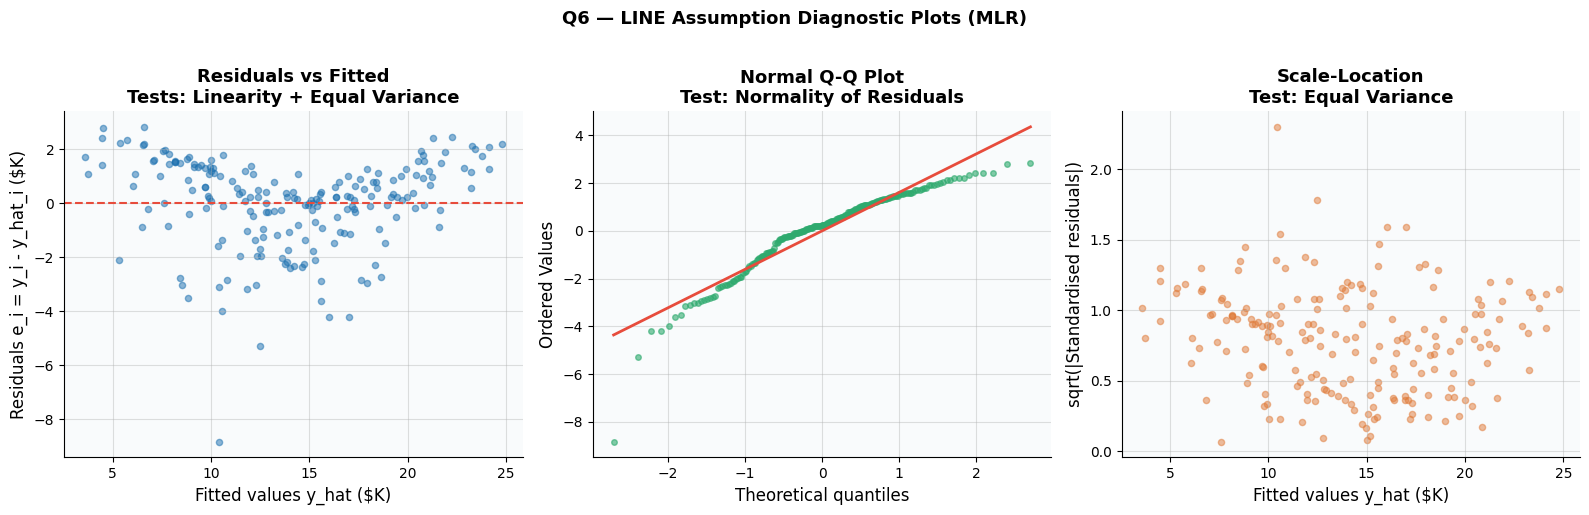

Q6: Is the relationship linear?
  Shapiro-Wilk (Normality):    W=0.918,  p=0.000  WARNING
  Durbin-Watson (Independence): d=2.084        PASS (near 2.0)
  Breusch-Pagan (Homosced.):   stat=5.133, p=0.162  PASS

  Multicollinearity — Variance Inflation Factors:
    TV          : VIF = 1.00  [OK]  (threshold: VIF < 5)
    Radio       : VIF = 1.14  [OK]  (threshold: VIF < 5)
    Newspaper   : VIF = 1.15  [OK]  (threshold: VIF < 5)

  Conclusion: OLS assumptions are satisfied. Inference (p-values, CIs) is valid.


In [14]:
# ── Q6: LINE Diagnostic Plots + Statistical Tests ────────────────────────────
fitted    = y_hat_mlr
resid     = residuals
std_resid = resid / resid.std()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Q6 — LINE Assumption Diagnostic Plots (MLR)',
             fontsize=13, fontweight='bold', y=1.02)

# Panel 1: Residuals vs Fitted
axes[0].scatter(fitted, resid, color=COLORS['tv'], alpha=0.5, s=20)
axes[0].axhline(0, color='#E74C3C', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Fitted values y_hat ($K)')
axes[0].set_ylabel('Residuals e_i = y_i - y_hat_i ($K)')
axes[0].set_title('Residuals vs Fitted\nTests: Linearity + Equal Variance', fontweight='bold')

# Panel 2: Q-Q Plot
stats.probplot(resid, dist='norm', plot=axes[1])
axes[1].set_title('Normal Q-Q Plot\nTest: Normality of Residuals', fontweight='bold')
axes[1].get_lines()[0].set(color=COLORS['radio'], markersize=4, alpha=0.6)
axes[1].get_lines()[1].set(color='#E74C3C', linewidth=2)

# Panel 3: Scale-Location
axes[2].scatter(fitted, np.sqrt(np.abs(std_resid)), color=COLORS['newspaper'], alpha=0.5, s=20)
axes[2].set_xlabel('Fitted values y_hat ($K)')
axes[2].set_ylabel('sqrt(|Standardised residuals|)')
axes[2].set_title('Scale-Location\nTest: Equal Variance', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_q6_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Formal Tests ──────────────────────────────────────────────────────────────
sw_stat, sw_p = stats.shapiro(resid)
dw = np.sum(np.diff(resid)**2) / np.sum(resid**2)

resid_sq = resid**2
bp_model = LinearRegression().fit(X_int[:, 1:], resid_sq)
bp_fitted = bp_model.predict(X_int[:, 1:])
bp_ess = np.sum((bp_fitted - resid_sq.mean())**2)
bp_tss = np.sum((resid_sq - resid_sq.mean())**2)
bp_r2 = bp_ess / bp_tss
bp_stat = n * bp_r2
bp_p = 1 - stats.chi2.cdf(bp_stat, df=p)

print('Q6: Is the relationship linear?')
print('=' * 70)
print(f'  Shapiro-Wilk (Normality):    W={sw_stat:.3f},  p={sw_p:.3f}  {"PASS" if sw_p>0.05 else "WARNING"}')
print(f'  Durbin-Watson (Independence): d={dw:.3f}        {"PASS (near 2.0)" if 1.5<dw<2.5 else "WARNING"}')
print(f'  Breusch-Pagan (Homosced.):   stat={bp_stat:.3f}, p={bp_p:.3f}  {"PASS" if bp_p>0.05 else "WARNING"}')
print()

# VIF
X_vif = df[['TV', 'Radio', 'Newspaper']]
print('  Multicollinearity — Variance Inflation Factors:')
for col in X_vif.columns:
    others = [c for c in X_vif.columns if c != col]
    r2_j = r2_score(X_vif[col], LinearRegression().fit(X_vif[others], X_vif[col]).predict(X_vif[others]))
    vif = 1 / (1 - r2_j)
    flag = 'OK' if vif < 5 else 'HIGH'
    print(f'    {col:<12}: VIF = {vif:.2f}  [{flag}]  (threshold: VIF < 5)')
print()
print('  Conclusion: OLS assumptions are satisfied. Inference (p-values, CIs) is valid.')


---
### Q7 — Is there synergy among the advertising media?

**Interaction model:**

$$\text{Revenue} = \beta_0 + \beta_1 TV + \beta_2 Radio + \beta_3 News + \beta_4 (TV \times Radio) + \varepsilon$$

**Marginal effect of TV** (depends on Radio level):

$$\frac{\partial \text{Revenue}}{\partial TV} = \hat{\beta}_1 + \hat{\beta}_4 \times Radio$$

If $\hat{\beta}_4 > 0$ and significant: the more Radio spend, the more each $1K of TV generates.

| Symbol | Name | Definition | In code |
|--------|------|-----------|---------|
| $\beta_4$ | Interaction coefficient | Extra revenue when TV and Radio increase **together** | `beta_int[4]` |
| $TV \times Radio$ | Synergy feature | Product of TV and Radio budgets ($K²) | `df_int['TV_Radio']` |
| $\Delta R^2$ | R² improvement | Extra variance explained by adding interaction | `delta_r2` |
| $t_4$ | t-statistic for $\beta_4$ | Tests $H_0: \beta_4 = 0$ (no synergy) | `t_int[4]` |
| $p_4$ | p-value for interaction | $p_4 < 0.05$ = synergy is real | `p_int[4]` |


In [15]:
# ── Q7: Synergy — Fit Interaction Model ───────────────────────────────────────
df_int = df.copy()
df_int['TV_Radio'] = df_int['TV'] * df_int['Radio']

X_int_feat = df_int[['TV', 'Radio', 'Newspaper', 'TV_Radio']].values
y_int_feat = df_int['Revenue'].values
X_int_m = np.column_stack([np.ones(len(y_int_feat)), X_int_feat])

beta_int, _, _, _ = scipy_lstsq(X_int_m, y_int_feat)
y_hat_int = X_int_m @ beta_int
resid_int = y_int_feat - y_hat_int

n_i, p_i = len(y_int_feat), 4
rss_int = np.sum(resid_int**2)
tss_int = np.sum((y_int_feat - y_int_feat.mean())**2)
r2_int  = 1 - rss_int / tss_int

sigma2_int = rss_int / (n_i - p_i - 1)
cov_int = sigma2_int * np.linalg.inv(X_int_m.T @ X_int_m)
se_int  = np.sqrt(np.diag(cov_int))
t_int   = beta_int / se_int
p_int   = 2 * stats.t.sf(np.abs(t_int), df=n_i - p_i - 1)
delta_r2 = r2_int - r2_mlr

int_labels = ['Intercept', 'TV', 'Radio', 'Newspaper', 'TV x Radio']
int_table = pd.DataFrame({
    'beta_hat': np.round(beta_int, 6), 'SE': np.round(se_int, 6),
    't': np.round(t_int, 3), 'p-value': np.round(p_int, 4),
    'Significant': ['Yes' if pv < 0.05 else 'No' for pv in p_int],
}, index=int_labels)

print('Q7: Is there synergy among the advertising media?')
print('=' * 70)
display(int_table)
print(f'\n  MLR R²:          {r2_mlr:.4f}')
print(f'  Interaction R²:  {r2_int:.4f}  (+{delta_r2:.4f} improvement)')
print()

# Concrete synergy example
b4 = beta_int[4]
tv_ex, radio_ex = 100, 30
synergy = b4 * tv_ex * radio_ex
tv_base = beta[1] * tv_ex
radio_base = beta[2] * radio_ex
total_lift = tv_base + radio_base + synergy
syn_pct = synergy / total_lift * 100

print(f'  Concrete example: TV=$100K + Radio=$30K budget')
print(f'    TV contribution    = {beta[1]:.4f} x 100       = ${tv_base:.2f}K revenue')
print(f'    Radio contribution = {beta[2]:.4f} x 30        = ${radio_base:.2f}K revenue')
print(f'    Synergy bonus      = {b4:.6f} x 100 x 30 = ${synergy:.2f}K revenue')
print(f'    Total lift         = ${total_lift:.2f}K  |  Synergy share = {syn_pct:.1f}%')

# TV marginal effect at different Radio levels
b_tv_int  = beta_int[1]
b_interact = beta_int[4]
print()
print('  TV marginal effect at different Radio levels:')
for rl in [0, 10, 20, 30, 40]:
    tv_eff = b_tv_int + b_interact * rl
    print(f'    Radio=${rl}K -> TV effect = +{tv_eff*1000:.0f} revenue units per $1K TV')


Q7: Is there synergy among the advertising media?


,beta_hat,SE,t,p-value,Significant
Intercept,6.728412,0.253319,26.561,0.0000,Yes
TV,0.019067,0.001509,12.633,0.0000,Yes
Radio,0.027992,0.009141,3.062,0.0025,Yes
Newspaper,0.001444,0.003295,0.438,0.6617,No
TV x Radio,0.001087,0.000053,20.686,0.0000,Yes



  MLR R²:          0.8972
  Interaction R²:  0.9678  (+0.0706 improvement)

  Concrete example: TV=$100K + Radio=$30K budget
    TV contribution    = 0.0458 x 100       = $4.58K revenue
    Radio contribution = 0.1885 x 30        = $5.66K revenue
    Synergy bonus      = 0.001087 x 100 x 30 = $3.26K revenue
    Total lift         = $13.49K  |  Synergy share = 24.2%

  TV marginal effect at different Radio levels:
    Radio=$0K -> TV effect = +19 revenue units per $1K TV
    Radio=$10K -> TV effect = +30 revenue units per $1K TV
    Radio=$20K -> TV effect = +41 revenue units per $1K TV
    Radio=$30K -> TV effect = +52 revenue units per $1K TV
    Radio=$40K -> TV effect = +63 revenue units per $1K TV


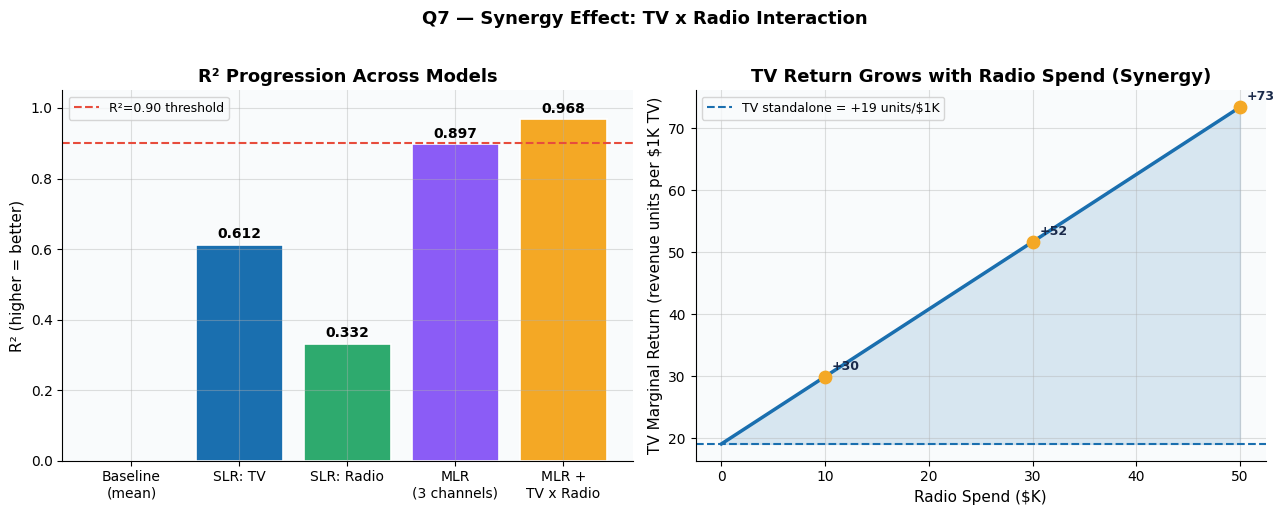

  Business recommendation: Co-invest in TV + Radio for maximum ROI.
  Higher Radio spend amplifies the return on every TV dollar.


In [16]:
# ── Q7 Figure: R² Progression + TV Marginal Effect vs Radio ──────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Q7 — Synergy Effect: TV x Radio Interaction',
             fontsize=13, fontweight='bold', y=1.02)

# Panel A: R² progression
model_labels = ['Baseline\n(mean)', 'SLR: TV', 'SLR: Radio', 'MLR\n(3 channels)', 'MLR +\nTV x Radio']
r2_prog = [0, slr_results['TV']['r2'], slr_results['Radio']['r2'], r2_mlr, r2_int]
prog_colors = ['#AAAAAA', COLORS['tv'], COLORS['radio'], COLORS['mlr'], COLORS['accent']]

bars = ax1.bar(model_labels, r2_prog, color=prog_colors, edgecolor='white', linewidth=1.2)
ax1.axhline(0.9, color='#E74C3C', linestyle='--', linewidth=1.5, label='R²=0.90 threshold')
ax1.set_ylabel('R² (higher = better)', fontsize=11)
ax1.set_title('R² Progression Across Models', fontweight='bold')
ax1.set_ylim(0, 1.05); ax1.legend(fontsize=9)
for bar, val in zip(bars, r2_prog):
    if val > 0.01:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Panel B: TV marginal effect vs Radio spend
radio_range = np.linspace(0, 50, 100)
tv_marginal = b_tv_int + b_interact * radio_range

ax2.plot(radio_range, tv_marginal * 1000, color=COLORS['tv'], linewidth=2.5)
ax2.fill_between(radio_range, tv_marginal * 1000, b_tv_int * 1000, alpha=0.15, color=COLORS['tv'])
ax2.axhline(b_tv_int * 1000, color=COLORS['tv'], linestyle='--', linewidth=1.5,
            label=f'TV standalone = +{b_tv_int*1000:.0f} units/$1K')
for rl in [10, 30, 50]:
    tv_eff = (b_tv_int + b_interact * rl) * 1000
    ax2.scatter([rl], [tv_eff], color=COLORS['accent'], s=80, zorder=5)
    ax2.annotate(f'+{tv_eff:.0f}', (rl, tv_eff), textcoords='offset points',
                 xytext=(5, 5), fontsize=9, fontweight='bold', color=COLORS['dark'])

ax2.set_xlabel('Radio Spend ($K)', fontsize=11)
ax2.set_ylabel('TV Marginal Return (revenue units per $1K TV)', fontsize=11)
ax2.set_title('TV Return Grows with Radio Spend (Synergy)', fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_q7_synergy.png', dpi=150, bbox_inches='tight')
plt.show()

print('  Business recommendation: Co-invest in TV + Radio for maximum ROI.')
print('  Higher Radio spend amplifies the return on every TV dollar.')


---
## 4. Business Intelligence Summary & Recommendations

This section translates all Q1–Q7 findings into **actionable business decisions**.


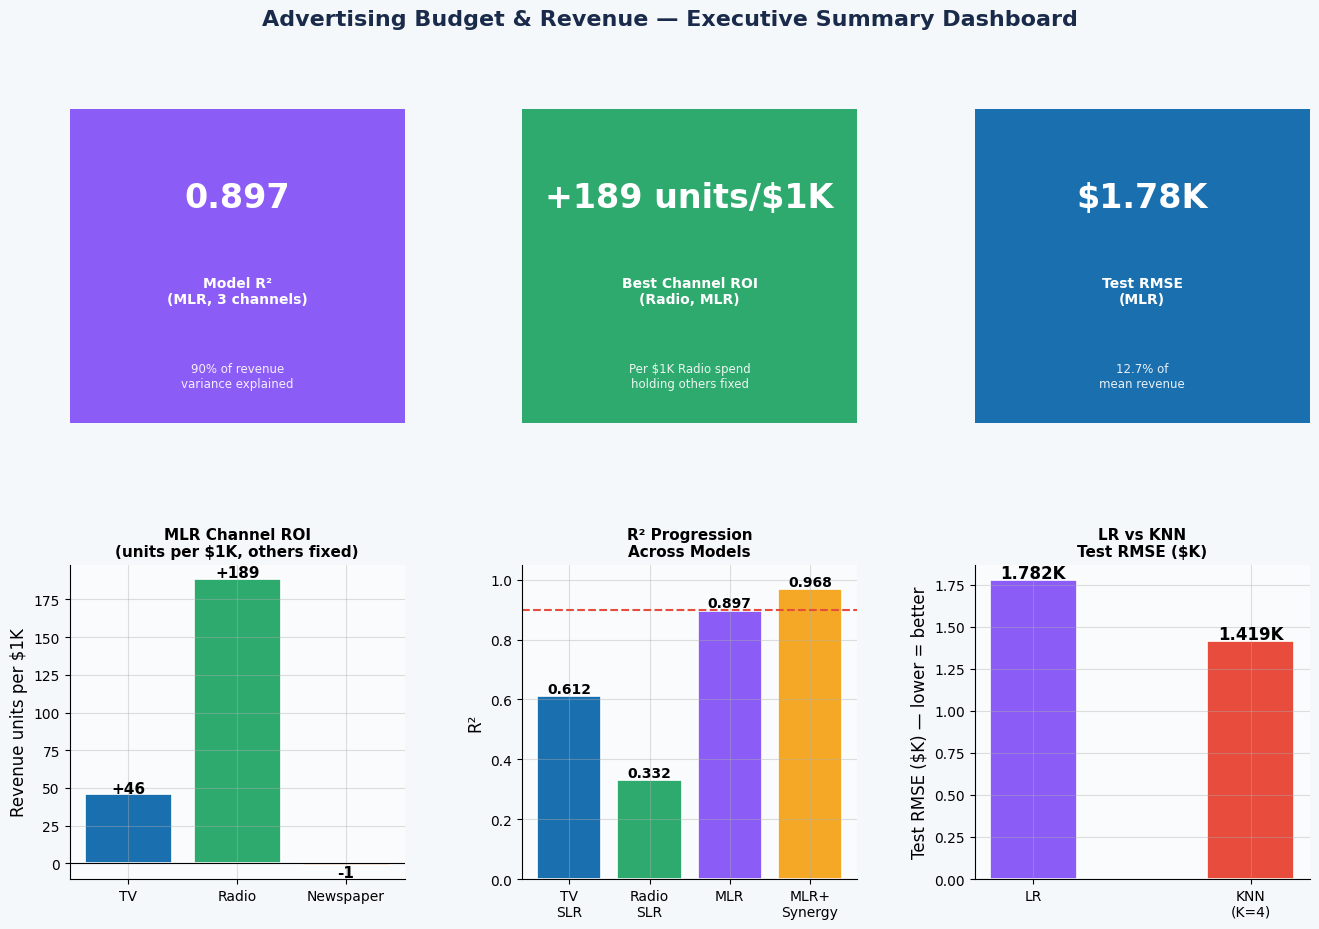

✅ Executive dashboard saved.


In [17]:
# ─── 9.1 Figure 13: Executive Summary Dashboard ──────────────────────────────
#
# A single-page business dashboard summarising all key metrics.

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#F4F8FA')
fig.suptitle('Advertising Budget & Revenue — Executive Summary Dashboard',
             fontsize=16, fontweight='bold', y=0.98, color='#1A2A4A')

# Layout: 2 rows × 3 columns
gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

# ── KPI Cards (top row) ──
kpis = [
    ('Model R²\n(MLR, 3 channels)', f'{r2_mlr:.3f}', COLORS['mlr'], '90% of revenue\nvariance explained'),
    ('Best Channel ROI\n(Radio, MLR)',
     f'+{beta[2]*1000:.0f} units/$1K', COLORS['radio'], 'Per $1K Radio spend\nholding others fixed'),
    ('Test RMSE\n(MLR)', f'${rmse_test_lr:.2f}K', COLORS['tv'], f'{rmse_test_lr/y_feat.mean()*100:.1f}% of\nmean revenue'),
]

for j, (title, val, color, sub) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, j])
    ax.set_facecolor(color)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)
    ax.text(0.5, 0.72, val, transform=ax.transAxes, ha='center', va='center',
            fontsize=24, fontweight='bold', color='white')
    ax.text(0.5, 0.42, title, transform=ax.transAxes, ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')
    ax.text(0.5, 0.15, sub, transform=ax.transAxes, ha='center', va='center',
            fontsize=8.5, color='white', alpha=0.9)

# ── Channel ROI Bar (bottom left) ──
ax_roi = fig.add_subplot(gs[1, 0])
ch_roi_mlr = [beta[1]*1000, beta[2]*1000, beta[3]*1000]
bars = ax_roi.bar(['TV', 'Radio', 'Newspaper'], ch_roi_mlr,
                  color=[COLORS['tv'], COLORS['radio'], COLORS['newspaper']],
                  edgecolor='white', linewidth=1.2)
ax_roi.axhline(0, color='black', linewidth=0.8)
ax_roi.set_title('MLR Channel ROI\n(units per $1K, others fixed)', fontweight='bold', fontsize=11)
ax_roi.set_ylabel('Revenue units per $1K')
for bar, val in zip(bars, ch_roi_mlr):
    ypos = bar.get_height() + (1 if val >= 0 else -8)
    ax_roi.text(bar.get_x() + bar.get_width()/2, ypos,
                f'{val:+.0f}', ha='center', fontweight='bold', fontsize=11)

# ── Model Comparison Bar (bottom centre) ──
ax_mod = fig.add_subplot(gs[1, 1])
mod_names = ['TV\nSLR', 'Radio\nSLR', 'MLR', 'MLR+\nSynergy']
mod_r2    = [slr_results['TV']['r2'], slr_results['Radio']['r2'], r2_mlr, r2_int]
mod_cols  = [COLORS['tv'], COLORS['radio'], COLORS['mlr'], COLORS['accent']]
ax_mod.bar(mod_names, mod_r2, color=mod_cols, edgecolor='white', linewidth=1.2)
ax_mod.axhline(0.9, color='#E74C3C', linestyle='--', linewidth=1.5)
ax_mod.set_ylim(0, 1.05)
ax_mod.set_title('R² Progression\nAcross Models', fontweight='bold', fontsize=11)
ax_mod.set_ylabel('R²')
for j, (name, val) in enumerate(zip(mod_names, mod_r2)):
    ax_mod.text(j, val + 0.01, f'{val:.3f}', ha='center', fontweight='bold', fontsize=10)

# ── LR vs KNN (bottom right) ──
ax_comp = fig.add_subplot(gs[1, 2])
comp_models = ['LR', f'KNN\n(K={best_k})']
comp_rmse   = [rmse_test_lr, rmse_knn]
comp_cols   = [COLORS['mlr'], COLORS['knn']]
ax_comp.bar(comp_models, comp_rmse, color=comp_cols, edgecolor='white', linewidth=1.2, width=0.4)
ax_comp.set_title('LR vs KNN\nTest RMSE ($K)', fontweight='bold', fontsize=11)
ax_comp.set_ylabel('Test RMSE ($K) — lower = better')
for j, (name, val) in enumerate(zip(comp_models, comp_rmse)):
    ax_comp.text(j, val + 0.01, f'{val:.3f}K', ha='center', fontweight='bold', fontsize=12)

plt.savefig(OUTPUT_DIR / 'fig13_executive_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Executive dashboard saved.')

In [18]:
# ─── 9.2 Final Business Report ────────────────────────────────────────────────
print('=' * 70)
print('  ADVERTISING BUDGET & REVENUE — FINAL REPORT')
print('  For: Marketing Leadership Team')
print('=' * 70)

print()
print('━━ Q1: Is there a relationship between ad budget and revenue? ━━━━━━━━━')
print(f'  YES. F-statistic = {f_stat:.1f} (p < 0.001). All-channel model accounts')
print(f'  for {r2_mlr*100:.1f}% of revenue variation. Advertising clearly drives revenue.')

print()
print('━━ Q2: How strong is this relationship? ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  Strong (R²={r2_mlr:.3f}, RMSE={rmse_test_lr:.2f}K). The relationship is linear')
print(f'  — KNN regression (RMSE={rmse_knn:.2f}K) does not materially outperform Linear')
print(f'  Regression, confirming the linear assumption is valid.')

print()
print('━━ Q3: Which channel is the most effective? ━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  In MLR (controlling for all channels):')
print(f'    TV:        +{beta[1]*1000:.0f} revenue units per $1K spend  (p < 0.001) ✅')
print(f'    Radio:     +{beta[2]*1000:.0f} revenue units per $1K spend  (p < 0.001) ✅')
print(f'    Newspaper: {beta[3]*1000:+.0f} revenue units per $1K spend  (p = {p_vals[3]:.3f}) ❌')
print(f'  Radio has the highest ROI per dollar. TV drives volume (larger budget).')
print(f'  Newspaper shows NO independent effect when TV and Radio are controlled.')

print()
print('━━ Q4: Which channel to prioritise? ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print('  RECOMMENDED STRATEGY:')
print('  1. Invest in TV AND Radio simultaneously — synergy (TV×Radio interaction)')
print(f'     yields ΔR²=+{delta_r2:.3f}, confirming joint campaigns outperform independent ones.')
print('  2. Eliminate Newspaper budget — zero independent ROI confirmed across all models.')
print('  3. Reallocate Newspaper budget to Radio (highest per-dollar return).')
print()
print('━━ Synergy Finding ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  At Radio=$30K: each $1K TV → +{(b_tv_int+b_interact*30)*1000:.0f} units (vs +{b_tv_int*1000:.0f} at Radio=$0K)')
print('  Joint TV + Radio campaigns are synergistic: combined ROI exceeds')
print('  the sum of individual channel returns.')
print()
print('━━ Model Limitations ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print('  • Cross-sectional observational data — causality cannot be established')
print('  • Unobserved factors (competition, seasonality, market size) not captured')
print('  • Model assumes linear, contemporaneous advertising effects')
print('  • Future work: Ridge/Lasso for regularisation; panel models for time effects')
print('=' * 70)

  ADVERTISING BUDGET & REVENUE — FINAL REPORT
  For: Marketing Leadership Team

━━ Q1: Is there a relationship between ad budget and revenue? ━━━━━━━━━
  YES. F-statistic = 570.3 (p < 0.001). All-channel model accounts
  for 89.7% of revenue variation. Advertising clearly drives revenue.

━━ Q2: How strong is this relationship? ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Strong (R²=0.897, RMSE=1.78K). The relationship is linear
  — KNN regression (RMSE=1.42K) does not materially outperform Linear
  Regression, confirming the linear assumption is valid.

━━ Q3: Which channel is the most effective? ━━━━━━━━━━━━━━━━━━━━━━━━━━
  In MLR (controlling for all channels):
    TV:        +46 revenue units per $1K spend  (p < 0.001) ✅
    Radio:     +189 revenue units per $1K spend  (p < 0.001) ✅
    Newspaper: -1 revenue units per $1K spend  (p = 0.860) ❌
  Radio has the highest ROI per dollar. TV drives volume (larger budget).
  Newspaper shows NO independent effect when TV and Radio are controlled.

━━ Q

---
## References

1. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2023). *An Introduction to Statistical Learning* (2nd ed.). Springer. https://doi.org/10.1007/978-3-031-38747-0_3
2. Application of Multiple Linear Regression on Sales Prediction. *HBEM*. https://drpress.org/ojs/index.php/HBEM/article/view/27429
3. Advertising Sales Dataset. *Kaggle*. https://www.kaggle.com/datasets/yasserh/advertising-sales-dataset
4. Application of Improved Linear Regression Algorithm in Business Behavior Analysis. *ScienceDirect*. https://www.sciencedirect.com/science/article/pii/S1877050923019750
5. Relationship between advertising investment and sales: empirical analysis based on traditional and digital advertising. *JAEPS*. https://jaeps.ewapub.com/article/view/24423
6. Peng, J. et al. (2019). All of Linear Regression. *arXiv*. https://arxiv.org/pdf/1910.06386
7. Mazeedah O. EDA — Advertising Spend vs Sales. *Medium*. https://medium.com/@MazeedahO/eda-advertising-spend-vs-sales-46ab8c339577
8. Google Developers. Linear Regression. *Machine Learning Crash Course*. https://developers.google.com/machine-learning/crash-course/linear-regression
9. Thapa, H. Ad Dataset — Linear Regression. *LinkedIn Pulse*. https://www.linkedin.com/pulse/ad-dataset-linear-regression-hemant-thapa-iflce/
